### Importing the libraries

In [1]:
#importing the required libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

### Data Exploration

In [2]:
#reading the dataset

df_ev = pd.read_csv('../dataset/Electric_Vehicle_Sales_by_State_India.csv')

df_ev.head(10)


,Year,Month_Name,Date,State,Vehicle_Class,Vehicle_Category,Vehicle_Type,EV_Sales_Quantity
0,2014.0,jan,1/1/2014,Andhra Pradesh,ADAPTED VEHICLE,Others,Others,0.0
1,2014.0,jan,1/1/2014,Andhra Pradesh,AGRICULTURAL TRACTOR,Others,Others,0.0
2,2014.0,jan,1/1/2014,Andhra Pradesh,AMBULANCE,Others,Others,0.0
3,2014.0,jan,1/1/2014,Andhra Pradesh,ARTICULATED VEHICLE,Others,Others,0.0
4,2014.0,jan,1/1/2014,Andhra Pradesh,BUS,Bus,Bus,0.0
5,2014.0,jan,1/1/2014,Andhra Pradesh,CASH VAN,Others,Others,0.0
6,2014.0,jan,1/1/2014,Andhra Pradesh,CRANE MOUNTED VEHICLE,Others,Others,0.0
7,2014.0,jan,1/1/2014,Andhra Pradesh,EDUCATIONAL INSTITUTION BUS,Bus,Institution Bus,0.0
8,2014.0,jan,1/1/2014,Andhra Pradesh,EXCAVATOR (COMMERCIAL),Others,Others,0.0
9,2014.0,jan,1/1/2014,Andhra Pradesh,FORK LIFT,Others,Others,0.0


In [3]:
#veiwing the number of rows and columns 
df_ev.shape 

(96845, 8)

In [4]:
#viewing the columns
df_ev.columns

Index(['Year', 'Month_Name', 'Date', 'State', 'Vehicle_Class',
       'Vehicle_Category', 'Vehicle_Type', 'EV_Sales_Quantity'],
      dtype='str')

In [5]:
#viewing the dataset information
df_ev.info()

<class 'pandas.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               96845 non-null  float64
 1   Month_Name         96845 non-null  str    
 2   Date               96845 non-null  str    
 3   State              96845 non-null  str    
 4   Vehicle_Class      96845 non-null  str    
 5   Vehicle_Category   96845 non-null  str    
 6   Vehicle_Type       96845 non-null  str    
 7   EV_Sales_Quantity  96845 non-null  float64
dtypes: float64(2), str(6)
memory usage: 10.8 MB


In [6]:
#viweing the numerical column info
df_ev.describe()

,Year,EV_Sales_Quantity
count,96845.000000,96845.000000
mean,2018.622768,37.108896
std,2.895581,431.566675
min,2014.000000,0.000000
25%,2016.000000,0.000000
50%,2019.000000,0.000000
75%,2021.000000,0.000000
max,2024.000000,20584.000000


In [7]:
#checking the null value
df_ev.isnull().sum()

Year                 0
Month_Name           0
Date                 0
State                0
Vehicle_Class        0
Vehicle_Category     0
Vehicle_Type         0
EV_Sales_Quantity    0
dtype: int64

In [8]:
#checking for duplicated values
df_ev.duplicated().sum()

0

### Data Processing

In [9]:
#changing all the column names to lowercase
df_ev.columns = df_ev.columns.str.strip().str.lower()

df_ev.columns

Index(['year', 'month_name', 'date', 'state', 'vehicle_class',
       'vehicle_category', 'vehicle_type', 'ev_sales_quantity'],
      dtype='str')

In [10]:
#changing the datatype of the column 'Date' from str to date format
df_ev['date'] = pd.to_datetime(df_ev['date'])

In [11]:
#changing the datatype of column 'Year' from float to int
df_ev['year'] = df_ev['year'].astype('int')

In [12]:
#changing the datatype of column 'EV_Sales_Quantity' from float to int
df_ev['ev_sales_quantity'] = df_ev['ev_sales_quantity'].astype('int')

In [13]:
#changing the datatype of category columns

categorical_columns = ['month_name', 'state', 'vehicle_class','vehicle_category', 'vehicle_type']
df_ev[categorical_columns] = df_ev[categorical_columns].astype('category')

In [14]:
df_ev.info()

<class 'pandas.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   year               96845 non-null  int32         
 1   month_name         96845 non-null  category      
 2   date               96845 non-null  datetime64[us]
 3   state              96845 non-null  category      
 4   vehicle_class      96845 non-null  category      
 5   vehicle_category   96845 non-null  category      
 6   vehicle_type       96845 non-null  category      
 7   ev_sales_quantity  96845 non-null  int32         
dtypes: category(5), datetime64[us](1), int32(2)
memory usage: 1.9 MB


### Feature Engineering

In [15]:
#deriving the month column
df_ev['month'] = df_ev['date'].dt.month

In [16]:
#deriving the day column
df_ev['day'] = df_ev['date'].dt.day

In [17]:
#creating the Vehicle segment based on vehicle category 

vehicle_size_group = {
    '2-Wheelers': '2W',
    '3-Wheelers': '3W',
    '4-Wheelers': '4W',
    'Bus': '4W',
    'Others': 'others'
}

df_ev['vehicle_segment'] = df_ev['vehicle_category'].map(vehicle_size_group)

In [18]:
#creating the vehilce usage based on vehicle type
conditions = [
    df_ev['vehicle_type'].str.contains(
        'GOODS|PASSENGER|TRANSPORT|SHARED|BUS',
        case=False,
        na=False
    ),
    df_ev['vehicle_type'].str.contains(
        'PRIVATE|PERSONAL',
        case=False,
        na=False
    )
]

choices = ['Commercial', 'Personal']

df_ev['usage_type'] = np.select(
    conditions,
    choices,
    default='Others'
)

In [19]:
#creating the region map based on state geographical location
region_map = {
    # North
    'Delhi': 'North',
    'Haryana': 'North',
    'Punjab': 'North',
    'Himachal Pradesh': 'North',
    'Jammu and Kashmir': 'North',
    'Ladakh': 'North',
    'Uttarakhand': 'North',
    'Chandigarh': 'North',

    # South
    'Tamil Nadu': 'South',
    'Karnataka': 'South',
    'Kerala': 'South',
    'Andhra Pradesh': 'South',
    'Telangana': 'South',
    'Puducherry': 'South',
    'Lakshadweep': 'South',

    # West
    'Maharashtra': 'West',
    'Gujarat': 'West',
    'Goa': 'West',
    'DNH and DD': 'West',

    # East
    'West Bengal': 'East',
    'Odisha': 'East',
    'Bihar': 'East',
    'Jharkhand': 'East',
    'Andaman & Nicobar Islands': 'East',

    # Central
    'Madhya Pradesh': 'Central',
    'Chhattisgarh': 'Central',
    'Uttar Pradesh': 'Central',

    # North-East
    'Assam': 'North-East',
    'Arunachal Pradesh': 'North-East',
    'Manipur': 'North-East',
    'Meghalaya': 'North-East',
    'Mizoram': 'North-East',
    'Nagaland': 'North-East',
    'Sikkim': 'North-East',
    'Tripura': 'North-East'
}

df_ev['state_region'] = df_ev['state'].map(region_map)

In [20]:
#calculating the rolling average for 3m state wise
df_ev['rolling_3m_avg'] = (
    df_ev.groupby('state')['ev_sales_quantity']
      .transform(lambda x: x.rolling(3).mean())
)

In [21]:
df_ev.info() #checking the column info

<class 'pandas.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   year               96845 non-null  int32         
 1   month_name         96845 non-null  category      
 2   date               96845 non-null  datetime64[us]
 3   state              96845 non-null  category      
 4   vehicle_class      96845 non-null  category      
 5   vehicle_category   96845 non-null  category      
 6   vehicle_type       96845 non-null  category      
 7   ev_sales_quantity  96845 non-null  int32         
 8   month              96845 non-null  int32         
 9   day                96845 non-null  int32         
 10  vehicle_segment    96845 non-null  str           
 11  usage_type         96845 non-null  str           
 12  state_region       91067 non-null  str           
 13  rolling_3m_avg     96777 non-null  float64       
dtypes: category(5), d

In [22]:
df_ev.columns

Index(['year', 'month_name', 'date', 'state', 'vehicle_class',
       'vehicle_category', 'vehicle_type', 'ev_sales_quantity', 'month', 'day',
       'vehicle_segment', 'usage_type', 'state_region', 'rolling_3m_avg'],
      dtype='str')

### Transferring data to postgresql


In [23]:
#loading dot env file
load_dotenv()

#reading the required values from .env file
db_username = os.getenv("DB_USER_NAME")
db_password = os.getenv("DB_PASSWORD")
db_localhost = os.getenv("DB_HOST")
db_port = os.getenv("DB_PORT")
db_name = os.getenv("DB")

#creating engine for transferring data
try:
    engine = create_engine(f"postgresql+psycopg2://{db_username}:{db_password}@{db_localhost}:{db_port}/{db_name}")
    print(f"Connected to {db_name} Successfully")
except Exception as E:
    print(f"Failed to Connect to {db_name}\n, Error Message = {E}")


Connected to Indian_EV_Sales Successfully


In [24]:
#transfering the data from our dataframe(df_ev) to posgresql database Indian_EV_Sales
table_name = "IND_EV_Sales_Data"
try:
    df_ev.to_sql(name=table_name, con=engine, if_exists="replace", index=False)
    print(f"Data is successfully exported to the table {table_name} under PostgreSQL DB {db_name}")
except Exception as E:
    print(f"Failed to write data, Error Message = {E}")

Data is successfully exported to the table IND_EV_Sales_Data under PostgreSQL DB Indian_EV_Sales


### Exploratory Data Analysis

EV Sales Overall : date
2014-01-01       232
2014-02-01       171
2014-03-01       220
2014-04-01       252
2014-05-01       186
               ...  
2023-09-01    127793
2023-10-01    139232
2023-11-01    152610
2023-12-01    141033
2024-01-01    143182
Name: ev_sales_quantity, Length: 121, dtype: int32

EV Sales Statewise :            date                     state  ev_sales_quantity
0    2014-01-01  Andaman & Nicobar Island                  0
1    2014-01-01            Andhra Pradesh                  1
2    2014-01-01         Arunachal Pradesh                  0
3    2014-01-01                     Assam                  0
4    2014-01-01                     Bihar                  0
...         ...                       ...                ...
4107 2024-01-01                Tamil Nadu               8715
4108 2024-01-01                   Tripura                507
4109 2024-01-01             Uttar Pradesh              27833
4110 2024-01-01               Uttarakhand               1234
4

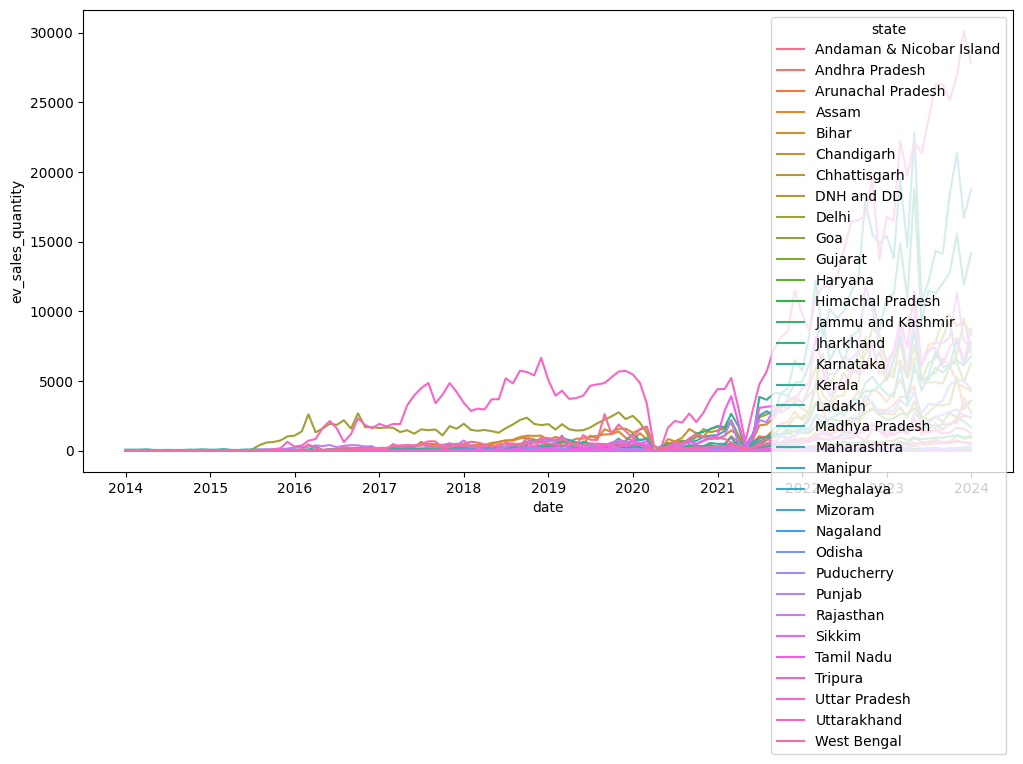

In [25]:
# 1. How are EV sales trending over time (overall + state-wise)?

#overall
ev_sales_overall = df_ev.groupby('date')['ev_sales_quantity'].sum()
print(f'EV Sales Overall : {ev_sales_overall}\n')

#state wise
ev_sales_state = df_ev.groupby(['date','state'])['ev_sales_quantity'].sum().reset_index()
print(f'EV Sales Statewise : {ev_sales_state}')
plt.figure(figsize=(12,6))
sns.lineplot(data=ev_sales_state, x='date', y='ev_sales_quantity', hue='state')
plt.show()

Top 5 State by Sales : ['Uttar Pradesh', 'Maharashtra', 'Karnataka', 'Delhi', 'Rajasthan']


<Axes: xlabel='date', ylabel='ev_sales_quantity'>

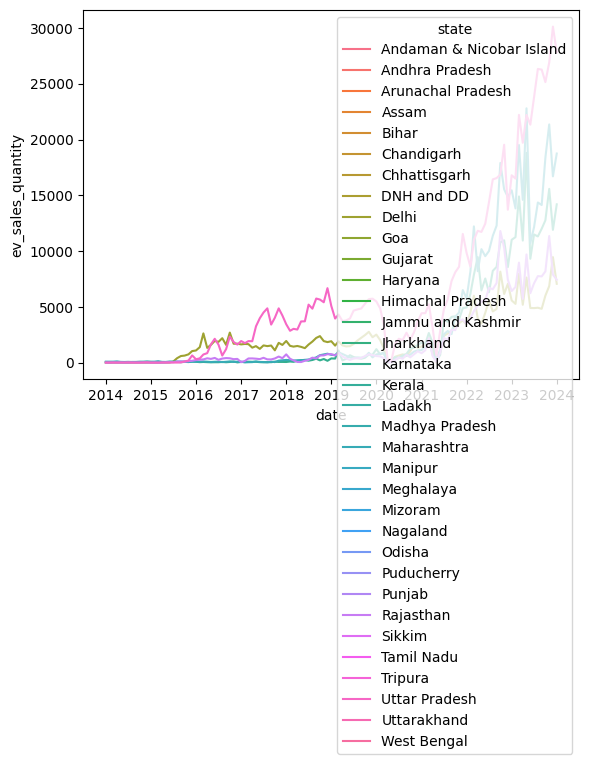

In [26]:
# 2. Top 5 states show fastest EV sales over time?

top_states = df_ev.groupby('state')['ev_sales_quantity'].sum().nlargest(5).index
print(f"Top 5 State by Sales : {list(top_states)}")

filtered = df_ev[df_ev['state'].isin(top_states)]

state_trend = filtered.groupby(['date','state'])['ev_sales_quantity'].sum().reset_index()
sns.lineplot(data=state_trend, x='date', y='ev_sales_quantity', hue='state')

State Wise 3M Rolling Average : state
Andaman & Nicobar Island       202.000000
Andhra Pradesh               77340.000000
Arunachal Pradesh               40.000000
Assam                       151917.000000
Bihar                       213465.000000
Chandigarh                   11440.666667
Chhattisgarh                 75275.000000
DNH and DD                     431.000000
Delhi                       268305.666667
Goa                          17380.666667
Gujarat                     176712.666667
Haryana                      85249.333333
Himachal Pradesh              2883.333333
Jammu and Kashmir            16701.000000
Jharkhand                    47871.000000
Karnataka                   315498.000000
Kerala                      133093.666667
Ladakh                          88.000000
Madhya Pradesh              133182.000000
Maharashtra                 401535.000000
Manipur                       1280.666667
Meghalaya                      208.000000
Mizoram                        235.000

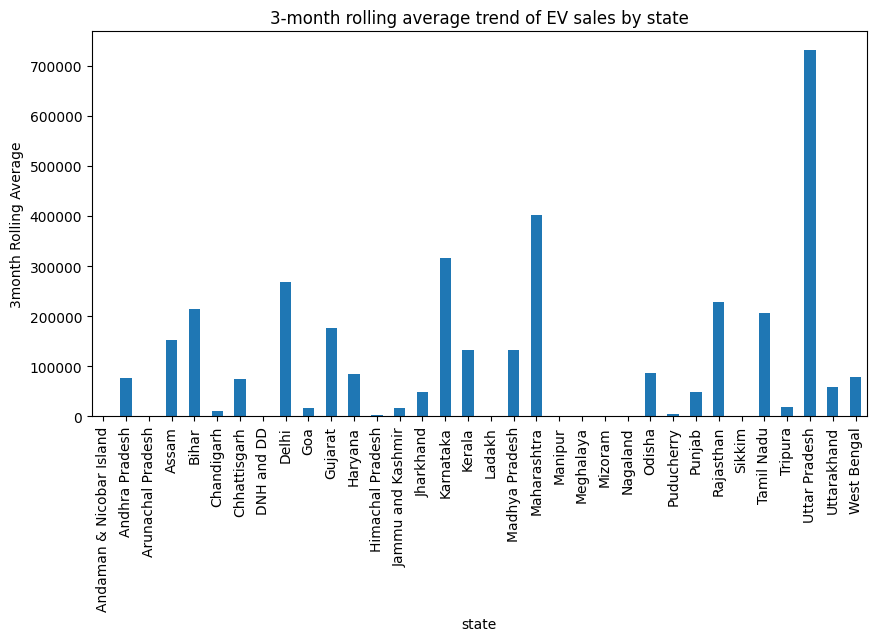

In [27]:
# 3. What is the 3-month rolling average trend of EV sales by state?

state_avg = df_ev.groupby('state')['rolling_3m_avg'].sum()

print(f"State Wise 3M Rolling Average : {state_avg}")

state_avg.plot(kind='bar', figsize=(10,5))
plt.title("3-month rolling average trend of EV sales by state")
plt.ylabel("3month Rolling Average")
plt.show()


EV sales by vehicle categories : vehicle_segment
2W        1808105
3W        1620310
4W         156784
others       8612
Name: ev_sales_quantity, dtype: int32


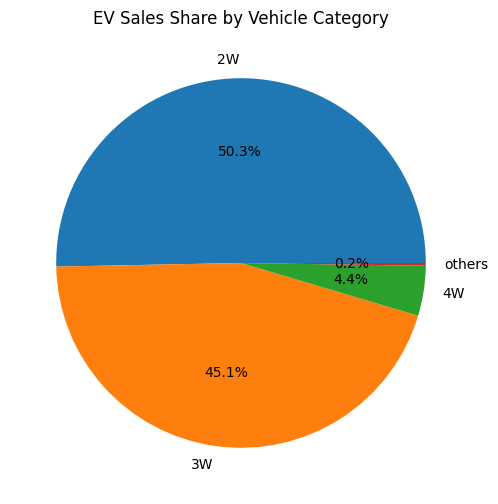

In [28]:
# 4. How do EV sales vary across vehicle categories (2W, 3W, 4W)?

ev_sales_category = df_ev.groupby('vehicle_segment')['ev_sales_quantity'].sum()

print(f"EV sales by vehicle categories : {ev_sales_category}")

plt.figure(figsize=(6,6))
plt.pie(
    ev_sales_category,
    labels=ev_sales_category.index,
    autopct='%1.1f%%'
)
plt.title("EV Sales Share by Vehicle Category")
plt.show()

vehicle_class
E-RICKSHAW(P)                1909.383863
M-CYCLE/SCOOTER              1493.903661
E-RICKSHAW WITH CART (G)      140.768557
MOTOR CAR                     123.268890
THREE WHEELER (PASSENGER)     100.795723
                                ...     
MODULAR HYDRAULIC TRAILER       0.000000
MOBILE CANTEEN                  0.000000
FIRE FIGHTING VEHICLE           0.000000
FIRE TENDERS                    0.000000
MOBILE WORKSHOP                 0.000000
Name: ev_sales_quantity, Length: 73, dtype: float64


Text(0, 0.5, 'Frequency')

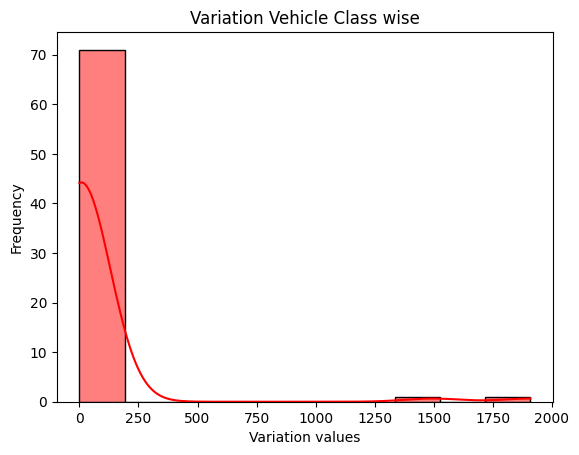

In [29]:
# 5. Which vehicle class shows highest variation? (Result -> Higher standard deviation = higher seasonal variation.)

variation = df_ev.groupby('vehicle_class')['ev_sales_quantity'].std().sort_values(ascending=False)
print(variation)


sns.histplot(variation, bins=10, kde=True, color="red")
plt.title("Variation Vehicle Class wise")
plt.xlabel("Variation values")
plt.ylabel("Frequency")

In [30]:
# 6. What is the market share of each state over time?
df_ev['total_sales_per_date'] = df_ev.groupby('date')['ev_sales_quantity'].transform('sum')

df_ev['market_share'] = (df_ev['ev_sales_quantity'] / df_ev['total_sales_per_date']) * 100

df_ev.tail(35)

,year,month_name,date,state,vehicle_class,vehicle_category,vehicle_type,ev_sales_quantity,month,day,vehicle_segment,usage_type,state_region,rolling_3m_avg,total_sales_per_date,market_share
96810,2023,dec,2023-12-01,Delhi,GOODS CARRIER,Others,Others,22,12,1,others,Others,North,75.000000,141033,0.015599
96811,2023,dec,2023-12-01,Delhi,MAXI CAB,Others,Others,0,12,1,others,Others,North,7.333333,141033,0.000000
96812,2023,dec,2023-12-01,Delhi,M-CYCLE/SCOOTER,2-Wheelers,2W_Personal,5380,12,1,2W,Personal,North,1800.666667,141033,3.814710
96813,2023,dec,2023-12-01,Delhi,M-CYCLE/SCOOTER-WITH SIDE CAR,2-Wheelers,2W_Personal,0,12,1,2W,Personal,North,1793.333333,141033,0.000000
96814,2023,dec,2023-12-01,Delhi,MOPED,2-Wheelers,2W_Personal,0,12,1,2W,Personal,North,1793.333333,141033,0.000000
96815,2023,dec,2023-12-01,Delhi,MOTOR CAB,4-Wheelers,4W_Shared,84,12,1,4W,Commercial,North,28.000000,141033,0.059561
96816,2023,dec,2023-12-01,Delhi,MOTOR CAR,4-Wheelers,4W_Personal,727,12,1,4W,Personal,North,270.333333,141033,0.515482
96817,2023,dec,2023-12-01,Delhi,THREE WHEELER (GOODS),3-Wheelers,3W_Goods,681,12,1,3W,Commercial,North,497.333333,141033,0.482866
96818,2023,dec,2023-12-01,Delhi,THREE WHEELER (PASSENGER),3-Wheelers,3W_Shared,8,12,1,3W,Commercial,North,472.000000,141033,0.005672
96819,2023,dec,2023-12-01,Goa,ADAPTED VEHICLE,Others,Others,0,12,1,others,Others,West,0.000000,141033,0.000000


sales differ across regions: state_region
Central       940531
East          426271
North         491946
North-East    172086
South         738141
West          596061
Name: ev_sales_quantity, dtype: int32


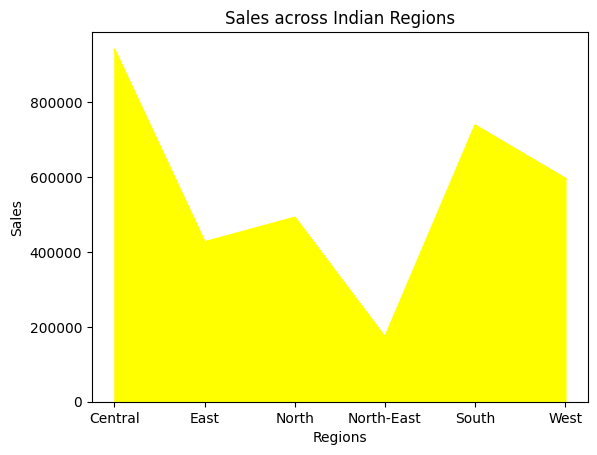

In [31]:
# 7. How do sales differ across regions of India?

sales_by_region = df_ev.groupby(['state_region'])['ev_sales_quantity'].sum()
print(f"sales differ across regions: {sales_by_region}")

sales_by_region.plot(kind="area", color="yellow")
plt.title("Sales across Indian Regions")
plt.xlabel("Regions")
plt.ylabel("Sales")
plt.show()

In [32]:
# 8. Which states have abnormal spikes or dips in EV sales?

Q1 = df_ev['ev_sales_quantity'].quantile(0.25)
print(f"Quartile 1: {Q1}")
Q3 = df_ev['ev_sales_quantity'].quantile(0.75)
print(f"Quartile 3: {Q3}")
IQR = Q3 - Q1
print(f"Inter Quartile Range: {IQR}")

outliers = df_ev[(df_ev['ev_sales_quantity'] < Q1 - 1.5*IQR) |
              (df_ev['ev_sales_quantity'] > Q3 + 1.5*IQR)]
print(f"Outliers:{outliers}")

Quartile 1: 0.0
Quartile 3: 0.0
Inter Quartile Range: 0.0
Outliers:       year month_name       date                     state  \
13     2014        jan 2014-01-01            Andhra Pradesh   
102    2014        jan 2014-01-01              Chhattisgarh   
153    2014        jan 2014-01-01                     Delhi   
157    2014        jan 2014-01-01                     Delhi   
173    2014        jan 2014-01-01                       Goa   
...     ...        ...        ...                       ...   
96833  2023        dec 2023-12-01                       Goa   
96837  2023        dec 2023-12-01  Andaman & Nicobar Island   
96839  2023        dec 2023-12-01  Andaman & Nicobar Island   
96840  2023        dec 2023-12-01  Andaman & Nicobar Island   
96841  2023        dec 2023-12-01  Andaman & Nicobar Island   

                           vehicle_class vehicle_category vehicle_type  \
13                       M-CYCLE/SCOOTER       2-Wheelers  2W_Personal   
102                      M-C

In [33]:
# 9. What is the cumulative EV adoption trend over time?

df_ev['ev_sales_cumlative'] = df_ev.groupby(['date','state'])['ev_sales_quantity'].cumsum()

ev_sales_cumlative_state = df_ev.groupby(['date','state'])['ev_sales_quantity'].cumsum()
print(f'EV Sales Overall : {ev_sales_cumlative_state}\n')

df_ev.tail(15)

EV Sales Overall : 0        0
1        0
2        0
3        0
4        0
        ..
96840    4
96841    9
96842    9
96843    9
96844    9
Name: ev_sales_quantity, Length: 96845, dtype: int32



,year,month_name,date,state,vehicle_class,vehicle_category,vehicle_type,ev_sales_quantity,month,day,vehicle_segment,usage_type,state_region,rolling_3m_avg,total_sales_per_date,market_share,ev_sales_cumlative
96830,2023,dec,2023-12-01,Goa,MOTOR CYCLE/SCOOTER-USED FOR HIRE,2-Wheelers,2W_Shared,0,12,1,2W,Commercial,West,23.666667,141033,0.000000,880
96831,2023,dec,2023-12-01,Goa,THREE WHEELER (GOODS),3-Wheelers,3W_Goods,0,12,1,3W,Commercial,West,0.000000,141033,0.000000,880
96832,2023,dec,2023-12-01,Goa,THREE WHEELER (PASSENGER),3-Wheelers,3W_Shared,2,12,1,3W,Commercial,West,0.666667,141033,0.001418,882
96833,2023,dec,2023-12-01,Goa,THREE WHEELER (PERSONAL),3-Wheelers,3W_Personal,1,12,1,3W,Personal,West,1.000000,141033,0.000709,883
96834,2023,dec,2023-12-01,Andaman & Nicobar Island,CONSTRUCTION EQUIPMENT VEHICLE,Others,Others,0,12,1,others,Others,NaN,0.000000,141033,0.000000,0
96835,2023,dec,2023-12-01,Andaman & Nicobar Island,GOODS CARRIER,Others,Others,0,12,1,others,Others,NaN,0.000000,141033,0.000000,0
96836,2023,dec,2023-12-01,Andaman & Nicobar Island,MAXI CAB,Others,Others,0,12,1,others,Others,NaN,0.000000,141033,0.000000,0
96837,2023,dec,2023-12-01,Andaman & Nicobar Island,M-CYCLE/SCOOTER,2-Wheelers,2W_Personal,2,12,1,2W,Personal,NaN,0.666667,141033,0.001418,2
96838,2023,dec,2023-12-01,Andaman & Nicobar Island,MOPED,2-Wheelers,2W_Personal,0,12,1,2W,Personal,NaN,0.666667,141033,0.000000,2
96839,2023,dec,2023-12-01,Andaman & Nicobar Island,MOTOR CAB,4-Wheelers,4W_Shared,1,12,1,4W,Commercial,NaN,1.000000,141033,0.000709,3


EV Sales in Finanical Year : 2014        623
2015       2347
2016      16192
2017      55875
2018      96506
2019     146944
2020     173558
2021     142397
2022     458897
2023    1182951
2024    1317521
Name: ev_sales_quantity, dtype: int32


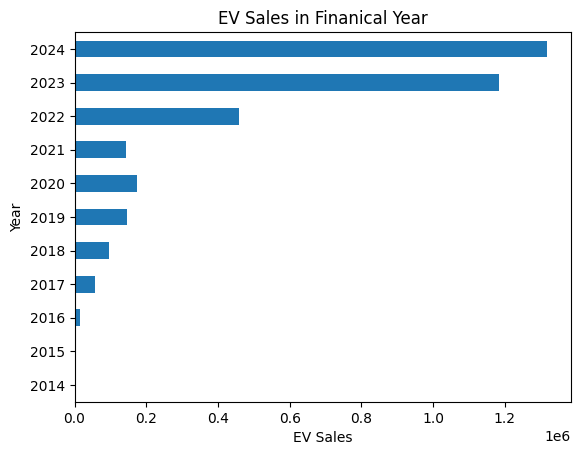

In [34]:
# 10. How does EV adoption differ by financial year?

finanical_year = df_ev['year'] +( df_ev['month'] >= 4)
EV_sales_finaical_year = df_ev.groupby(finanical_year)['ev_sales_quantity'].sum()

print(f"EV Sales in Finanical Year : {EV_sales_finaical_year}")

EV_sales_finaical_year.plot(kind="barh")
plt.title("EV Sales in Finanical Year")
plt.xlabel('EV Sales')
plt.ylabel('Year')
plt.show()


In [35]:
df_ev.info()

<class 'pandas.DataFrame'>
RangeIndex: 96845 entries, 0 to 96844
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   year                  96845 non-null  int32         
 1   month_name            96845 non-null  category      
 2   date                  96845 non-null  datetime64[us]
 3   state                 96845 non-null  category      
 4   vehicle_class         96845 non-null  category      
 5   vehicle_category      96845 non-null  category      
 6   vehicle_type          96845 non-null  category      
 7   ev_sales_quantity     96845 non-null  int32         
 8   month                 96845 non-null  int32         
 9   day                   96845 non-null  int32         
 10  vehicle_segment       96845 non-null  str           
 11  usage_type            96845 non-null  str           
 12  state_region          91067 non-null  str           
 13  rolling_3m_avg        96777